In [ ]:
Esistono gruppi di generi che producono un profitto simile?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# importo le nuove librerie
# l'ho trovata cercando online (pagina principale: https://scikit-learn.org/stable/)
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

import matplotlib.ticker as ticker

df = pd.read_pickle('Film.pickle')
# Inizializzazione dello stile
plt.style.use('seaborn-v0_8-whitegrid')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Action'),
  Text(1, 0, 'Adventure'),
  Text(2, 0, 'Comedy'),
  Text(3, 0, 'Concert or Performance'),
  Text(4, 0, 'Dark Comedy'),
  Text(5, 0, 'Documentary'),
  Text(6, 0, 'Drama'),
  Text(7, 0, 'Horror'),
  Text(8, 0, 'Multiple Genres'),
  Text(9, 0, 'Musical'),
  Text(10, 0, 'Reality'),
  Text(11, 0, 'Romantic Comedy'),
  Text(12, 0, 'Thriller or Suspense'),
  Text(13, 0, 'Western')])

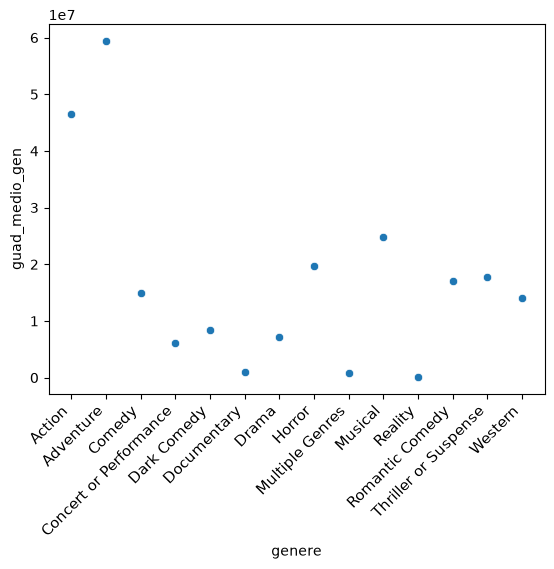

In [7]:
df_temp = df.groupby('genere')[['lordo', 'film_usciti']].sum().reset_index()
df_temp.columns = ['genere', 'incasso_tot', 'film_tot']
#df_temp
df_temp['guad_medio_gen'] = df_temp['incasso_tot']/df_temp['film_tot']
#df_temp
ax = sns.scatterplot(data=df_temp, x='genere', y='guad_medio_gen', marker='o')


# Ruoto le scritte
plt.xticks(rotation=45, ha='right', fontsize=11)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Adventure'),
  Text(1, 0, 'Action'),
  Text(2, 0, 'Drama'),
  Text(3, 0, 'Comedy'),
  Text(4, 0, 'Thriller or Suspense'),
  Text(5, 0, 'Horror'),
  Text(6, 0, 'Romantic Comedy'),
  Text(7, 0, 'Musical'),
  Text(8, 0, 'Documentary'),
  Text(9, 0, 'Dark Comedy'),
  Text(10, 0, 'Western'),
  Text(11, 0, 'Concert or Performance'),
  Text(12, 0, 'Multiple Genres'),
  Text(13, 0, 'Reality')])

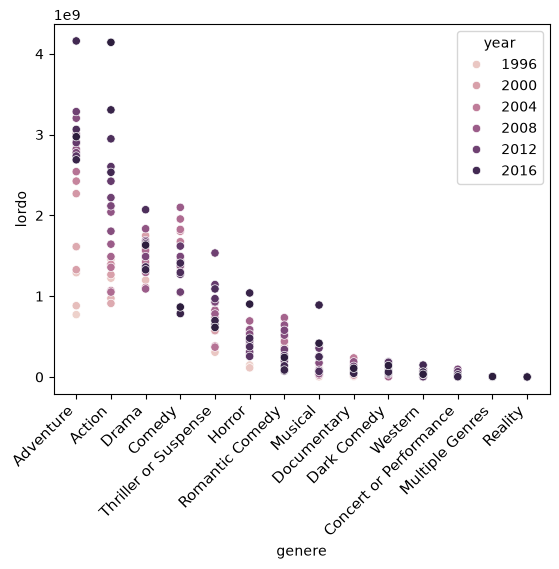

In [6]:
sns.scatterplot(data=df, x='genere', y='lordo', hue='year')

plt.xticks(rotation=45, ha='right', fontsize=11)

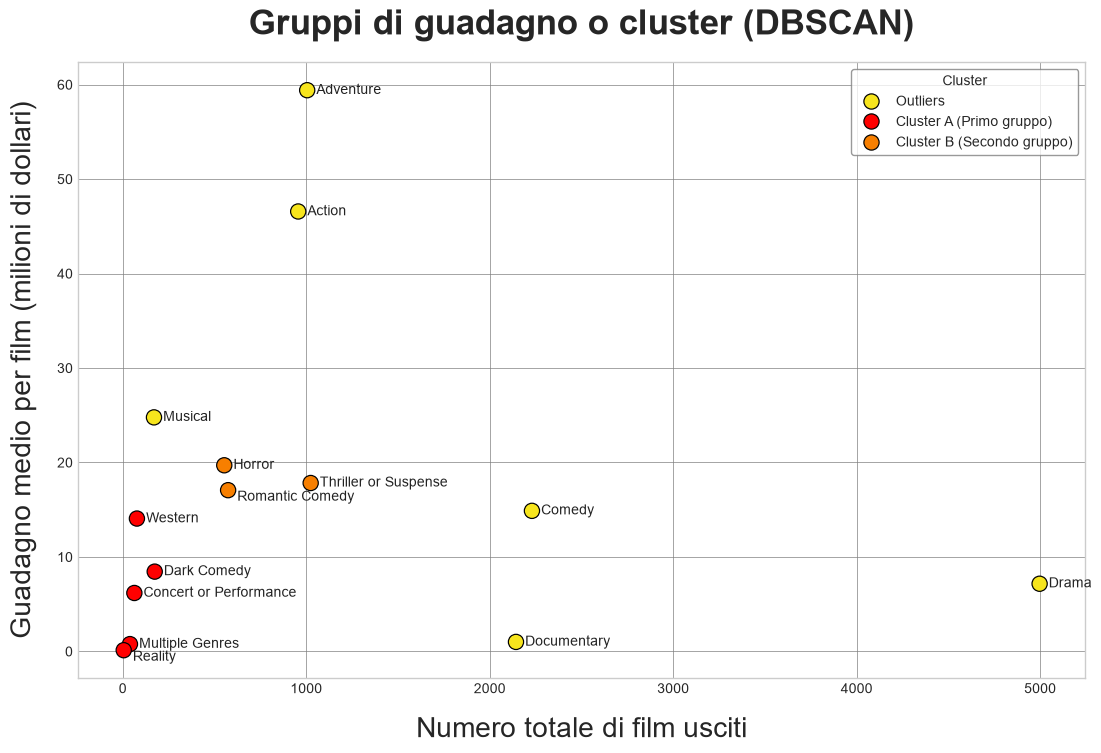

In [3]:
df_temp = df.groupby('genere')[['lordo', 'film_usciti']].sum().reset_index()
df_temp.columns = ['genere', 'incasso_tot', 'film_tot']
df_temp['guad_medio_gen'] = df_temp['incasso_tot'] / df_temp['film_tot']

# Standardizzazione se no i valori in milioni mi sballano DBSCAN
a = df_temp[['film_tot', 'guad_medio_gen']]
scaler = StandardScaler()
out = scaler.fit_transform(a)

# applico dbscan
dbscan = DBSCAN(eps=0.4, min_samples=2)
df_temp['cluster'] = dbscan.fit_predict(out)
'''
eps=0.7 --> 2 cluster, troppo pochi
eps=0.6 --> ||
eps=0.5 --> ||
eps=0.4 --> 3 cluster, compreso quello degli outliers, non male
eps=0.3 --> 3 cluster ma considera come outliers anche punti vicini, troppo piccolo il raggio

0.43 e 0.42 crea solo due cluster
0.41 si comporta come 0.40 con 3 cluster diverse
vado di 0.4, è più tondo
'''

# uso delle labels da assegnare ai cluster
cluster_labels = {
    '-1': 'Outliers', # perchè DBSCAN ritorna -1 per outlier e numeri crescenti per il resto
    '0': 'Cluster A (Primo gruppo)',
    '1': 'Cluster B (Secondo gruppo)',
}
#converto i numeri creati da DBSCAN in stringa e li sostituisco con le label
df_temp['cluster_stringa'] = df_temp['cluster'].astype(str).map(cluster_labels)

'''
# colori dinamici
nCluster = df_temp['cluster_stringa'].nunique() # uso il numero di colori che mi servono
colori = sns.color_palette("YlOrRd", nCluster)
'''
# grafico
plt.figure(figsize=(13, 8))
ax = sns.scatterplot(data=df_temp, 
                     x='film_tot', 
                     y='guad_medio_gen', 
                     hue='cluster_stringa', 
                     palette= ['#f7e51d', '#FF0000', '#F77F00'],
                     s=120, 
                     edgecolor='black',
                     zorder = 3 # per mettere i puntini davanti alla griglia
)
'''
palettes
set1
viridis
inferno
'''
# assi
plt.title('Gruppi di guadagno o cluster (DBSCAN)', fontsize=25, fontweight='bold', pad=20)
plt.xlabel('Numero totale di film usciti', fontsize=20, fontweight='normal', labelpad=15)
plt.ylabel('Guadagno medio per film (milioni di dollari)', fontsize=20, fontweight='normal', labelpad=15)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x * 1e-6:.0f}"))

# legenda
plt.legend(title='Cluster', frameon=True, facecolor='white', edgecolor='gray')

# aggiungo il nome di ogni genere
for i in range(df_temp.shape[0]):
    if i==10 or i==11: # solto le iterazioni sugli indici che si sovrappongono
        continue
    plt.text(x = df_temp['film_tot'].iloc[i] + 50,
             y = df_temp['guad_medio_gen'].iloc[i], 
             s = df_temp['genere'].iloc[i],
             horizontalalignment='left', 
             verticalalignment='center',
             fontsize=10, 
             color='#222222', 
             weight='normal'
    )
# metto le label manualmente dove si sovrapporrebbero
plt.text(# reality
    x = df_temp['film_tot'].iloc[10] + 50, 
    y = df_temp['guad_medio_gen'].iloc[10], 
    s = df_temp['genere'].iloc[10],
    horizontalalignment='left', 
    verticalalignment='top',
    fontsize=10, 
    color='#222222', 
    weight='normal'
)
plt.text(# romantic comedy
    x = df_temp['film_tot'].iloc[11] + 50, 
    y = df_temp['guad_medio_gen'].iloc[11], 
    s = df_temp['genere'].iloc[11],
    horizontalalignment='left', 
    verticalalignment='top',
    fontsize=10, 
    color='#222222', 
    weight='normal'
)

ax.grid(True, which='major', color='gray', linestyle='-', linewidth=0.5, zorder=1)
#df_temp['genere']

# Salvataggio
plt.savefig("figures/3_1.png", bbox_inches='tight')
plt.savefig("figures/3_1.svg", bbox_inches='tight')